# Aprendizaje Profundo
## Tarea 3 - Redes Basadas en Atención
### Eduardo García


### Clasificación de rostros por grupo etario mediante ViT
Entrena y evalúa modelos de clasificación de rostros por grupo etario basados en la arquitectura ViT, usando el conjunto de datos FairFace. Agrega un bloque ResNet después de la capa convolucional que procesa los parches en ViT, entrena un modelo con la arquitecturañ modificada y compara su desempeño con ViT. Disctuteñ los resultados que obtuviste con las diferentes configuraciones. Para reducir el tiempo de entrenamiento puedes usar resoluciones de imágenes más pequeñas, como 64x64 o incluso 32x32.

### Bibliotecas

In [1]:
# funciones aleatorias
import random
# tomar n elementos de una secuencia
from itertools import islice as take
# gráficas
import matplotlib.patches as patches
import matplotlib.pyplot as plt
# arreglos multidimensionales
import numpy as np
# csv
import pandas as pd
# redes neuronales
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as T
# cargador de datos
from torch.utils.data import DataLoader, Dataset
# inspección de arquitectura
from torchinfo import summary
# barra de progreso
from tqdm.auto import trange
# imágenes
from PIL import Image

from einops import rearrange

### Funciones auxiliaries

In [2]:
def set_seed(seed=42):
  """Initializes pseudo-random number generators."""
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)


# reproducibilidad
set_seed()

## Dataset

In [3]:
df_train = pd.read_csv('./fairface_label_train.csv')
df_val = pd.read_csv('./fairface_label_val.csv')


In [4]:
df_train.age = pd.Categorical(df_train.age)
df_val.age = pd.Categorical(df_val.age)

df_train['age_ind'] = df_train.age.cat.codes
df_val['age_ind'] = df_val.age.cat.codes

In [5]:
df_train.head(10)

,file,age,gender,race,service_test,age_ind
0,train/1.jpg,50-59,Male,East Asian,True,6
1,train/2.jpg,30-39,Female,Indian,False,4
2,train/3.jpg,3-9,Female,Black,False,3
3,train/4.jpg,20-29,Female,Indian,True,2
4,train/5.jpg,20-29,Female,Indian,True,2
5,train/6.jpg,20-29,Male,White,True,2
6,train/7.jpg,40-49,Male,Middle Eastern,False,5
7,train/8.jpg,30-39,Female,Indian,True,4
8,train/9.jpg,10-19,Male,White,True,1
9,train/10.jpg,30-39,Male,Middle Eastern,False,4


In [6]:
df_val.head(10)

,file,age,gender,race,service_test,age_ind
0,val/1.jpg,3-9,Male,East Asian,False,3
1,val/2.jpg,50-59,Female,East Asian,True,6
2,val/3.jpg,30-39,Male,White,True,4
3,val/4.jpg,20-29,Female,Latino_Hispanic,True,2
4,val/5.jpg,20-29,Male,Southeast Asian,False,2
5,val/6.jpg,30-39,Male,Latino_Hispanic,False,4
6,val/7.jpg,20-29,Male,Black,True,2
7,val/8.jpg,3-9,Male,East Asian,False,3
8,val/9.jpg,20-29,Male,Southeast Asian,False,2
9,val/10.jpg,3-9,Male,Southeast Asian,False,3


In [7]:
df_train.age_ind.unique() 

array([6, 4, 3, 2, 5, 1, 7, 0, 8], dtype=int8)

In [8]:
df_train.age.unique()

['50-59', '30-39', '3-9', '20-29', '40-49', '10-19', '60-69', '0-2', 'more than 70']
Categories (9, object): ['0-2', '10-19', '20-29', '3-9', ..., '40-49', '50-59', '60-69', 'more than 70']

In [9]:
df_val.age_ind.unique()

array([3, 6, 4, 2, 8, 5, 1, 7, 0], dtype=int8)

In [10]:
# tamaño de la imagen
IMG_SIZE = 64

In [11]:
# transformación de entrenamiento
tr_ent = T.Compose([
  # Aplicamos un randon size crop para tener imágenes más pequeñas 
  # (y por ende más rápidas de procesar)
  T.RandomResizedCrop(64, scale=(.85, 1.0), antialias=True), #64x64 como en el notebook
  # Giramos aleatoriamente en el eje horizontal
  T.RandomHorizontalFlip(),
  # Hacemos una rotación aleatoria
  T.RandomRotation(degrees=90),
  # Por ultimo hacemos que la imagen sea un tensor
  # T.ToImage(),
  # T.ToDtype(th.float32, scale=True)
  T.ToTensor()
])

In [12]:
# transformación de validación
tr_val = T.Compose([
  T.Resize(64, antialias=True),
  # T.ToImage(),
  # T.ToDtype(th.float32, scale=True)
  T.ToTensor()
])

In [13]:
def muestra_imagenes(imgs, etiq):
  t_muestra = imgs.shape[0]
  n_filas = n_cols = int(np.sqrt(t_muestra))

  fig, ax = plt.subplots(nrows=n_filas, ncols=n_cols, figsize=(2 * n_filas,
                                                               2 * n_cols))
  for i in range(n_filas):
    for j in range(n_cols):
      idx = i * n_filas + j
      ax[i, j].imshow(imgs[idx])
      ax[i, j].axis('off')
      ax[i, j].set_title(etiq[idx])
  plt.tight_layout()
  plt.show()

In [14]:
# Definimos el DataLoader

class FaceLoader(Dataset):
  def __init__(self, df, root, transform=None):
    self.df = df
    self.root = root
    self.transform = transform

  def __getitem__(self, idx):
    # Abrimos la imagen
    img = Image.open(self.root + self.df.file.iloc[idx])
    # Obtenemos la categoría del dataframe
    cat = self.df.age_ind.iloc[idx]

    # En caso de tener una transformación
    if self.transform:
      img = self.transform(img)

    return img, torch.tensor(cat, dtype=torch.long)
  
  def __len__(self):
    return len(self.df)

In [15]:
rootDir = './fairface-img-margin025-trainval/'

In [16]:
import os
import zipfile

In [17]:
# Checamos si el archivo está o si necesitamos descomprimirlo
if not os.path.isdir(rootDir):
  with zipfile.ZipFile('./fairface-img-margin025-trainval.zip', 'r') as zip_ref:
    zip_ref.extractall(rootDir)

In [18]:
ds_ent = FaceLoader(df=df_train, root=rootDir)
ds_val = FaceLoader(df=df_val, root=rootDir)

In [19]:
# Definimos un iterador para poder ir cargando las imágenes
it_ent = iter(ds_ent)
img_ent, cat_ent = next(it_ent)

print(f'{img_ent = }, {cat_ent = }')

img_ent = <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=224x224 at 0x7FA478D39340>, cat_ent = tensor(6)


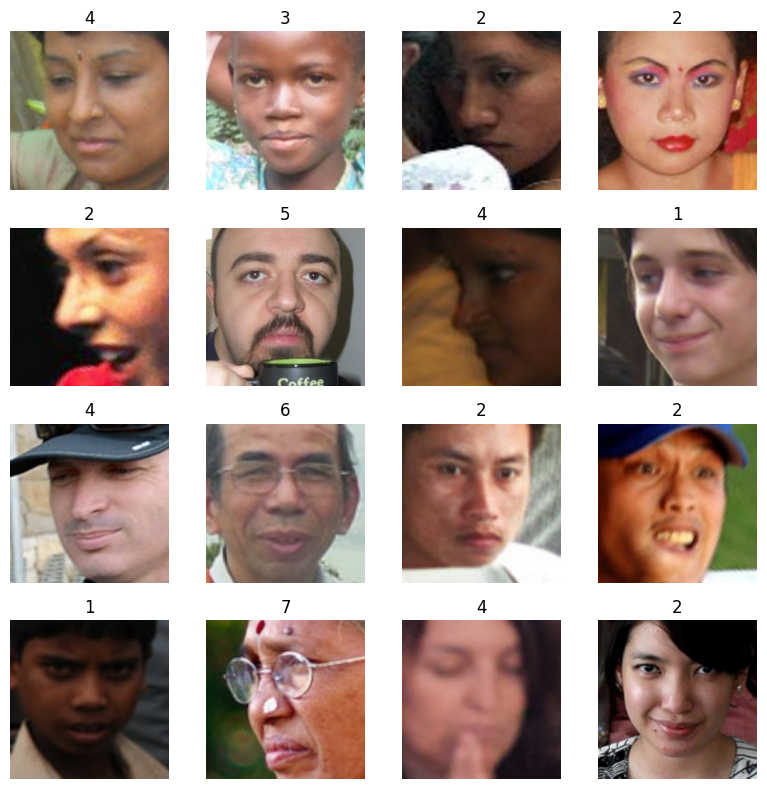

In [20]:
muestras = [next(it_ent) for i in range(16)]
imgs = [np.array(m[0]) for m in muestras]
cats = [m[1] for m in muestras]

muestra_imagenes(np.array(imgs), np.array(cats))

In [21]:
ds_ent.transform  = tr_ent
ds_val.transform  = tr_val

In [22]:
# Definimos un iterador para poder ir cargando las imágenes
it_ent = iter(ds_ent)
img_ent, cat_ent = next(it_ent)

print(f'{img_ent.shape = }, {cat_ent = }')

img_ent.shape = torch.Size([3, 64, 64]), cat_ent = tensor(6)


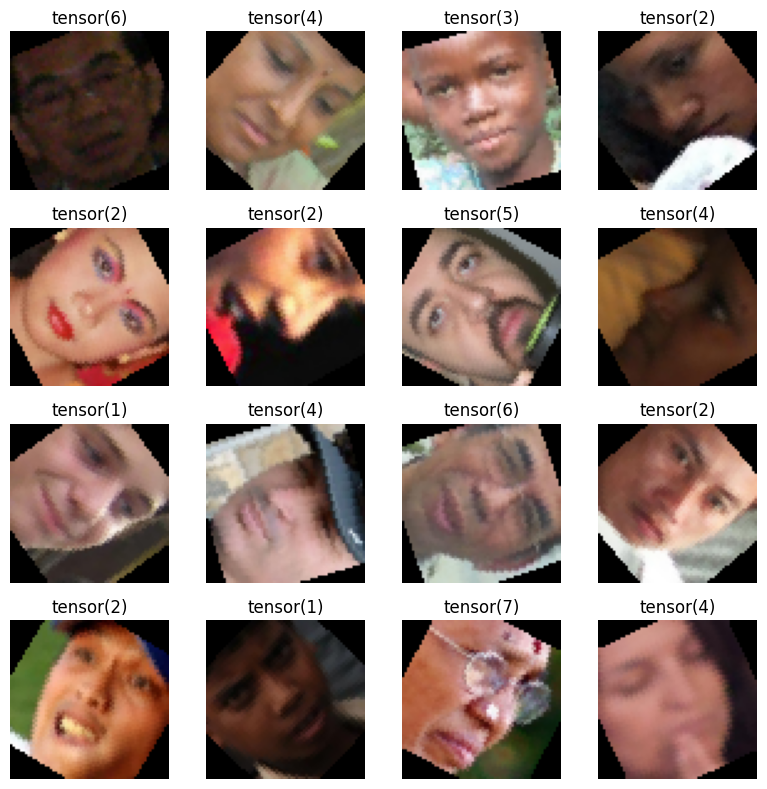

In [23]:
it = iter(ds_ent)
muestras = [next(it) for i in range(16)]
imgs = [np.array(m[0].permute(1, 2, 0)) for m in muestras]
cats = [m[1] for m in muestras]

muestra_imagenes(np.array(imgs), cats)

In [24]:
from torch.utils.data import DataLoader

In [25]:
T_LOTE = 64

In [26]:
entdl = DataLoader(ds_ent,
                   batch_size=T_LOTE,
                   shuffle=True)

valdl = DataLoader(ds_val,
                   batch_size=T_LOTE,
                   shuffle=True)

In [27]:
train_batch = next(iter(entdl))

In [28]:
train_batch[0].shape

torch.Size([64, 3, 64, 64])

## Modelo

In [29]:
class ProductoPuntoEscalado(nn.Module):
  def __init__(self,
               masc = False):
    super(ProductoPuntoEscalado, self).__init__()
    self.masc = masc

  def forward(self, Q, K, V):
    # Obtenemos dimensiones
    m, n_cabezas, l, d_k = K.shape
    d_v = V.shape[-1]

    # Cambiamos la forma: [m, n_cabezas, l, d_k] -> [m * n_cabezas, l, d_k]
    Q = Q.reshape(m * n_cabezas, l, d_k)
    K = K.reshape(m * n_cabezas, l, d_k)
    V = V.reshape(m * n_cabezas, l, d_v)

    # Q y K tienen forma [m * n_cabezas, l, d_k],
    # por lo que se transponen las dos últimas dimensiones de K
    # QK: [m * n_cabezas, l, l]
    QK = torch.bmm(Q, K.transpose(1, 2))

    # se escalan los valores QK
    QK_esc = QK / torch.math.sqrt(d_k)

    if self.masc:
      # Creamos una matriz triangular superior binaria (excluyendo la diagonal)
      masc = torch.triu(torch.ones((l, l), dtype = torch.bool, device = Q.device),
                     diagonal = 1)
      # Ponemos los valores de QK_esc en los que la máscara sea 1 a -inf
      QK_esc = QK_esc.masked_fill_(masc, -torch.inf)

    # mapas de atención: [m * n_cabezas, l, l] -> [m * n_cabezas, l, l]
    alfas = nn.functional.softmax(QK_esc, dim=-1)

    # vectores de salida y
    # alfas: [m * n_cabezas, l, l], V: [m * n_cabezas, l, d_v]
    # Y: [m * n_cabezas, l, d_v]
    Y = torch.bmm(alfas, V)

    # Cambiamos la forma: [m * n_cabezas, l, d_v] -> [m, n_cabezas, l, d_v]
    Y = Y.reshape(m, n_cabezas, l, d_v)

    # Cambiamos la forma: [m * n_cabezas, l, l] -> [m, n_cabezas, l, l]
    alfas = alfas.reshape(m, n_cabezas, l, l)

    return Y, alfas


In [30]:
class AtencionMulticabeza(nn.Module):
  def __init__(self,
               d_modelo,
               n_cabezas,
               masc = False):
    super(AtencionMulticabeza, self).__init__()

    self.n_cabezas = n_cabezas
    self.d_modelo = d_modelo

    self.ppe = ProductoPuntoEscalado(masc = masc)
    self.proy_Q = nn.Linear(self.d_modelo, self.d_modelo, bias = False)
    self.proy_K = nn.Linear(self.d_modelo, self.d_modelo, bias = False)
    self.proy_V = nn.Linear(self.d_modelo, self.d_modelo, bias = False)
    self.proy_sal = nn.Linear(self.d_modelo, self.d_modelo)

  def forward(self, x):
    m, l, d_modelo = x.shape

    # Cambiamos la forma del tensor x
    # [m, l, d_modelo] -> [m * l, d_modelo]
    x = x.reshape(m * l, d_modelo)

    # Proyectamos vectores en x a Q, K, V
    # [m * l, d_modelo] -> [m * l, d_modelo]
    Q = self.proy_Q(x)
    K = self.proy_K(x)
    V = self.proy_V(x)

    # Cambiamos la forma: [m * l, d_modelo] -> [m, l, n_cabezas, d_k]
    # d_k = d_v = self.d_modelo // self.n_cabezas
    Q = Q.reshape(m, l, self.n_cabezas, self.d_modelo // self.n_cabezas)
    K = K.reshape(m, l, self.n_cabezas, self.d_modelo // self.n_cabezas)
    V = V.reshape(m, l, self.n_cabezas, self.d_modelo // self.n_cabezas)

    # Transponemos el eje de las cabezas a la segunda posición del tensor y
    # creamos copia (con .contiguous()) para que esté almacenado en memoria de
    # forma contigua (.transpose() hace que ya no sea así).
    # [m, l, n_cabezas, d_k] -> [m, n_cabezas, l, d_k]
    Q = Q.transpose(1, 2).contiguous()
    K = K.transpose(1, 2).contiguous()
    V = V.transpose(1, 2).contiguous()

    # Calculamos el producto punto escalado con Q, K y V
    # Q, K: [m, n_cabezas, l, d_k], V:[m, n_cabezas, l, d_v]
    # Y: [m, n_cabezas, l, d_v], alfas: [m, n_cabezas, l, l]
    Y, alfas = self.ppe(Q, K, V)

    # Transponermos el eje de cabezas a la penúltima posición:
    # [m, n_cabezas, l, d_k] -> [m, l, n_cabezas, d_k]
    Y = Y.transpose(1, 2).contiguous()

    # Concatemanos los vectores de todas las cabezas en un solo vector
    # [m, l, n_cabezas, d_k] -> [m * l, d_modelo]
    # d_modelo = n_cabezas * d_k
    Y = Y.reshape(m * l, self.d_modelo)

    # Proyectamos la vectores concatenados para obtener la salida
    # [m * l, d_modelo] -> [m * l, d_modelo]
    Y = self.proy_sal(Y)

    # Concatemanos los vectores de todas las cabezas en un solo vector
    # [m * l, d_modelo] -> [m, l, d_modelo]
    Y = Y.reshape(m, l, self.d_modelo)

    return Y, alfas

In [31]:
amc = AtencionMulticabeza(32, 2)
amc(torch.ones([1, 256, 32]))[0].shape

torch.Size([1, 256, 32])

In [32]:
class RedDensaPosicion(nn.Module):
  def __init__(self,
               d_modelo,
               d_ff,
               p_dropout):

    super(RedDensaPosicion, self).__init__()
    self.d_modelo = d_modelo
    self.d_ff = d_ff

    self.densa1 = nn.Linear(self.d_modelo, self.d_ff)
    self.densa2 = nn.Linear(self.d_ff, self.d_modelo)

    self.dropout1 = nn.Dropout(p_dropout)
    self.dropout2 = nn.Dropout(p_dropout)

  def forward(self, x):
    m, l, d_modelo = x.shape

    # Cambiamos la forma: [m, l, d_modelo] -> [m * l, d_modelo]
    x = x.reshape(m * l, d_modelo)

    # Pasamos el tensor redimensionado por la red densa
    # [m * l, d_modelo] -> [m * l, d_modelo]
    x = self.densa1(x)
    x = nn.functional.gelu(x)
    x = self.dropout1(x)

    x = self.densa2(x)
    x = self.dropout2(x)

    # Lo regresamos a su forma original
    # [m * l, d_modelo] -> [m, l, d_modelo]
    x = x.reshape(m, l, d_modelo)

    return x

In [33]:
class BloqueTransformer(nn.Module):
  def __init__(self,
               d_modelo,
               n_cabezas,
               d_rdp,
               p_dropout = 0.0,
               masc = False):
    super(BloqueTransformer, self).__init__()

    self.amc = AtencionMulticabeza(d_modelo = d_modelo,
                                   n_cabezas = n_cabezas,
                                   masc = masc)
    self.norm1 = nn.LayerNorm(d_modelo)
    self.norm2 = nn.LayerNorm(d_modelo)

    self.dropout1 = nn.Dropout(p_dropout)

    self.mlp = RedDensaPosicion(d_modelo, d_rdp, p_dropout)

  def forward(self, x):
    x_ln1 = self.norm1(x)
    salidas_amc, alfas = self.amc(x_ln1)
    salidas_amc = self.dropout1(salidas_amc)

    x = salidas_amc + x
    x_ln2 = self.norm2(x)
    mlp = self.mlp(x_ln2)
    out = mlp + x

    return out

In [34]:
test_layer = BloqueTransformer(64, 2, 256)
test_layer(torch.ones([1, 64, 64])).shape

torch.Size([1, 64, 64])

In [35]:
summary(test_layer, (1, 64, 64), device='cpu')

Layer (type:depth-idx)                   Output Shape              Param #
BloqueTransformer                        [1, 64, 64]               --
├─LayerNorm: 1-1                         [1, 64, 64]               128
├─AtencionMulticabeza: 1-2               [1, 64, 64]               --
│    └─Linear: 2-1                       [64, 64]                  4,096
│    └─Linear: 2-2                       [64, 64]                  4,096
│    └─Linear: 2-3                       [64, 64]                  4,096
│    └─ProductoPuntoEscalado: 2-4        [1, 2, 64, 32]            --
│    └─Linear: 2-5                       [64, 64]                  4,160
├─Dropout: 1-3                           [1, 64, 64]               --
├─LayerNorm: 1-4                         [1, 64, 64]               128
├─RedDensaPosicion: 1-5                  [1, 64, 64]               --
│    └─Linear: 2-6                       [64, 256]                 16,640
│    └─Dropout: 2-7                      [64, 256]                 

### ViT Normal

In [36]:
class ViT(nn.Module):
    def __init__(self, img_size, patch_size, out_dim, d_modelo,
                 depth, n_cabezas, mlp_dim, dropout):
        super().__init__()
        self.d_modelo = d_modelo
        self.patch_size = patch_size
        # N = H*W/(P^2)
        self.n_patches = (img_size // patch_size) ** 2

        input_projection = 3*(patch_size ** 2) # C*PP

        self.projection = nn.Linear(input_projection, d_modelo) #

        self.pos_embedding = nn.Parameter(
            torch.randn(1, self.n_patches + 1, d_modelo))


        self.cls_token = nn.Parameter(torch.randn(1, 1, d_modelo))

        bloques = [BloqueTransformer(d_modelo,
                                     n_cabezas,
                                     mlp_dim,
                                     dropout,
                                     masc = False) for _ in range(depth)]
        self.transformer = nn.Sequential(*bloques)

        self.mlp_head = nn.Sequential(
            nn.LayerNorm(d_modelo),
            nn.Linear(d_modelo, out_dim),
        )

    def forward(self, x):
        B = x.shape[0]

        # Patches
        # N x (P^2 * C)
        # Donde:
        # N = HW/P^2

        #img_patches0 = x.reshape(B, self.n_patches, int((patch_size*patch_size)*C))

        img_patches = rearrange(x,
                        'b c (patch_x x) (patch_y y) -> b (x y) (c patch_x patch_y) ',
                        patch_x=self.patch_size, patch_y=self.patch_size)

        # Linear Projection
        x = self.projection(img_patches)

        cls_token = self.cls_token.repeat(B, 1, 1)
        x = torch.cat((cls_token, x), dim=1)
        x += self.pos_embedding

        x = self.transformer(x)
        x = x[:, 0, :]
        return self.mlp_head(x)

### ViT Residual

In [37]:
class Residual(nn.Module):
  def __init__(self,
               cent,
               csal,
               downsample = False):
    super(Residual, self).__init__()

    stride = 1

    if downsample:
      stride = 2

    if cent != csal or downsample:
      self.conv1x1 = nn.Conv2d(cent, csal, 1, stride = stride, padding = 0)
    else:
      self.conv1x1 = None

    self.conv1 = nn.Conv2d(cent, csal, 3, stride = stride, padding = 1)
    self.bn1 = nn.BatchNorm2d(csal)
    self.conv2 = nn.Conv2d(csal, csal, 3, padding = 'same')
    self.bn2 = nn.BatchNorm2d(csal)

  def forward(self, x):
    y = self.conv1(x)
    y = self.bn1(y)
    y = nn.functional.relu(y)
    y = self.conv2(y)
    y = self.bn2(y)

    if self.conv1x1:
      x = self.conv1x1(x)

    return nn.functional.relu(x + y)

In [38]:
class ViTRes(nn.Module):
  def __init__(self, img_size, patch_size, out_dim, d_modelo,
                depth, n_cabezas, mlp_dim, dropout):
    super().__init__()
    self.d_modelo = d_modelo
    self.patch_size = patch_size
    # N = H*W/(P^2)
    self.n_patches = (img_size // patch_size) ** 2

    input_projection = 3*(patch_size ** 2) # C*PP

    # self.projection = nn.Linear(input_projection, d_modelo) 
    self.projection = Residual(input_projection, d_modelo)
    self.pos_embedding = nn.Parameter(
        torch.randn(1, self.n_patches + 1, d_modelo))


    self.cls_token = nn.Parameter(torch.randn(1, 1, d_modelo))

    bloques = [BloqueTransformer(d_modelo,
                                  n_cabezas,
                                  mlp_dim,
                                  dropout,
                                  masc = False) for _ in range(depth)]
    self.transformer = nn.Sequential(*bloques)
  
    self.mlp_head = nn.Sequential(
        nn.LayerNorm(d_modelo),
        nn.Linear(d_modelo, out_dim),
    )

  def forward(self, x):
    B = x.shape[0]

    # Patches
    # N x (P^2 * C)
    # Donde:
    # N = HW/P^2

    #img_patches0 = x.reshape(B, self.n_patches, int((patch_size*patch_size)*C))

    img_patches = rearrange(x,
                    'b c (patch_x x) (patch_y y) -> b (patch_x patch_y c) x y',
                    patch_x=self.patch_size, patch_y=self.patch_size)

    # print(f'{img_patches.shape = }')
    # Linear Projection
    x = self.projection(img_patches)
    # print(f'projection {x.shape = }')
    x = x.reshape(B, self.n_patches, 64)
    # print(f'reshape {x.shape = }')
    cls_token = self.cls_token.repeat(B, 1, 1)
    # print(f'{cls_token.shape = }')
    x = torch.cat((cls_token, x), dim=1)
    # print(f'cat {x.shape = }')
    x += self.pos_embedding

    x = self.transformer(x)
    x = x[:, 0, :]
    return self.mlp_head(x)

In [39]:
patch_size = 16
out_dim = 9
d_modelo = 64
depth = 3

n_cabezas = 4
mlp_dim = 256
dropout = 0.5

vit = ViT(IMG_SIZE, patch_size, out_dim, d_modelo, depth, n_cabezas, mlp_dim, dropout)

test_out = vit(train_batch[0])
test_out.shape

torch.Size([64, 9])

In [40]:
patch_size = 16
out_dim = 9
d_modelo = 64
depth = 3

n_cabezas = 4
mlp_dim = 256
dropout = 0.5

vitres = ViTRes(IMG_SIZE, patch_size, out_dim, d_modelo, depth, n_cabezas, mlp_dim, dropout)

test_out = vit(train_batch[0])
test_out.shape

torch.Size([64, 9])

In [41]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


## Entrenamiento

In [42]:
def train_epoch(dl, model, opt, device):
    """Entrena una época"""
    model.train()
    epoch_loss = 0
    epoch_acc = 0
    # entrenamiento de una época
    for batch in dl:
        x = batch[0].to(device)
        y_true = batch[1].to(device)
        # computamos logits
        y_lgts = model(x)

        # Para obtener el Accuracy:
        # computamos las probabilidades
        y_prob = F.softmax(y_lgts, 1)
        # obtenemos la clase predicha
        y_pred = torch.argmax(y_prob, 1)

        # computamos la pérdida
        loss = F.cross_entropy(y_lgts, y_true)

        # computamos la exactitud
        acc = (y_true == y_pred).type(torch.float32).mean()

        # vaciamos los gradientes
        opt.zero_grad()
        # retropropagamos
        loss.backward()

        # actualizamos parámetros
        opt.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    trn_loss = epoch_loss / len(dl)
    trn_acc = epoch_acc / len(dl)

    return trn_loss, trn_acc

In [43]:
def eval_epoch(dl, model, device, num_batches=None):
    """Evalua una época"""

    # Modelo en modo de evaluación
    # Congelar las estadísticas σ y μ
    model.eval()

    # evitamos que se registren las operaciones
    # en la gráfica de cómputo
    with torch.no_grad():

        losses, accs = [], []
        # validación de la época con num_batches
        # si num_batches==None, se usan todos los lotes
        for batch in take(dl, num_batches):
            x = batch[0].to(device)
            y_true = batch[1].to(device)
            # hacemos inferencia para obtener los logits
            y_lgts = model(x)
            # computamos las probabilidades
            y_prob = F.softmax(y_lgts, 1)
            # obtenemos la clase predicha
            y_pred = torch.argmax(y_prob, 1)

            # computamos la pérdida
            loss = F.cross_entropy(y_lgts, y_true)
            # computamos la exactitud
            acc = (y_true == y_pred).type(torch.float32).mean()

            # guardamos históricos
            losses.append(loss.item())
            accs.append(acc.item())

        loss = np.mean(losses)
        acc = np.mean(accs)

        return loss, acc

In [44]:
def train(model, trn_dl, val_dl, epochs,
          trn_batches=None, val_batches=None):

    train_losses = []
    val_losses = []

    train_accs = []
    val_accs = []

    # optimizador
    opt = optim.Adam(model.parameters(), lr=0.0001)

    # usamos GPU si está disponible
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    # movemos a dispositivo
    model.to(device)

    # ciclo de entrenamiento
    for epoch in trange(epochs):

        # entrenamos la época
        trn_loss , trn_acc = train_epoch(trn_dl, model, opt, device)
        # evaluamos la época en validación
        val_loss, val_acc = eval_epoch(val_dl, model, device, val_batches)

        train_losses.append(trn_loss)
        val_losses.append(val_loss)

        train_accs.append(trn_acc)
        val_accs.append(val_acc)

        print(f'\nEpoch {epoch}: Train loss: {trn_loss:4f} Train Accuracy: {trn_acc:4f}')
        print(f'Val loss: {val_loss:4f} Val Accuracy: {val_acc:4f}')

    return train_losses, val_losses, train_accs, val_accs

In [45]:
# entrenamos modelo
model = vit
train_losses, val_losses, train_accs, val_accs =train(model, entdl, valdl, epochs=15)

  0%|          | 0/15 [00:00<?, ?it/s]


Epoch 0: Train loss: 1.875073 Train Accuracy: 0.287426
Val loss: 1.837841 Val Accuracy: 0.297620

Epoch 1: Train loss: 1.852984 Train Accuracy: 0.291720
Val loss: 1.833827 Val Accuracy: 0.305214

Epoch 2: Train loss: 1.843945 Train Accuracy: 0.293699
Val loss: 1.816444 Val Accuracy: 0.303488

Epoch 3: Train loss: 1.834132 Train Accuracy: 0.295319
Val loss: 1.812214 Val Accuracy: 0.306359

Epoch 4: Train loss: 1.826787 Train Accuracy: 0.295569
Val loss: 1.822280 Val Accuracy: 0.298674

Epoch 5: Train loss: 1.820365 Train Accuracy: 0.297586
Val loss: 1.813682 Val Accuracy: 0.308467

Epoch 6: Train loss: 1.818187 Train Accuracy: 0.299898
Val loss: 1.819038 Val Accuracy: 0.301435

Epoch 7: Train loss: 1.816344 Train Accuracy: 0.299049
Val loss: 1.807613 Val Accuracy: 0.312082

Epoch 8: Train loss: 1.815434 Train Accuracy: 0.300343
Val loss: 1.796351 Val Accuracy: 0.314735

Epoch 9: Train loss: 1.812864 Train Accuracy: 0.301523
Val loss: 1.808969 Val Accuracy: 0.307467

Epoch 10: Train los

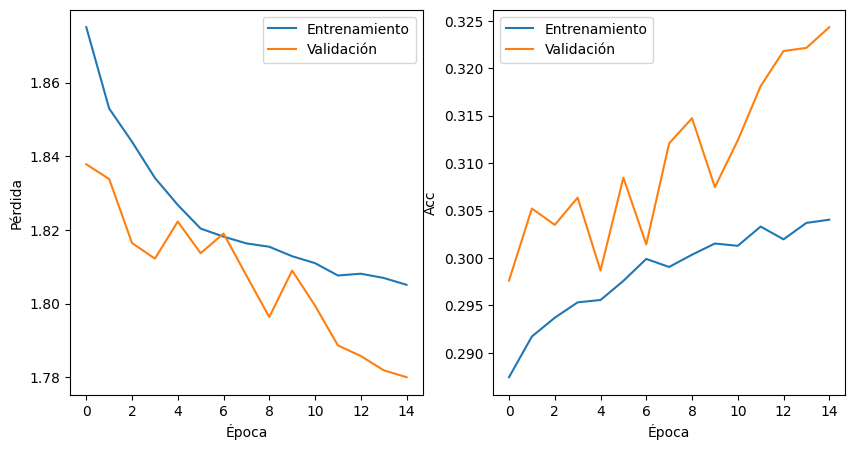

In [46]:
f,axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

axs[0].plot(train_losses, label='Entrenamiento')
axs[0].plot(val_losses, label='Validación')
axs[0].set_xlabel('Época')
axs[0].set_ylabel('Pérdida')
axs[0].legend()

axs[1].plot(train_accs, label='Entrenamiento')
axs[1].plot(val_accs, label='Validación')
axs[1].set_xlabel('Época')
axs[1].set_ylabel('Acc')
axs[1].legend()
plt.show()

In [47]:
# entrenamos modelo
model = vitres
train_losses, val_losses, train_accs, val_accs =train(model, entdl, valdl, epochs=15)

  0%|          | 0/15 [00:00<?, ?it/s]


Epoch 0: Train loss: 1.861134 Train Accuracy: 0.290656
Val loss: 1.816385 Val Accuracy: 0.295258

Epoch 1: Train loss: 1.810450 Train Accuracy: 0.301065
Val loss: 1.801265 Val Accuracy: 0.314608

Epoch 2: Train loss: 1.784411 Train Accuracy: 0.312085
Val loss: 1.778659 Val Accuracy: 0.323310

Epoch 3: Train loss: 1.769075 Train Accuracy: 0.316936
Val loss: 1.808047 Val Accuracy: 0.296039

Epoch 4: Train loss: 1.756104 Train Accuracy: 0.323543
Val loss: 1.751069 Val Accuracy: 0.327180

Epoch 5: Train loss: 1.744767 Train Accuracy: 0.325202
Val loss: 1.771716 Val Accuracy: 0.336810

Epoch 6: Train loss: 1.735681 Train Accuracy: 0.327088
Val loss: 1.751180 Val Accuracy: 0.325055

Epoch 7: Train loss: 1.726652 Train Accuracy: 0.330165
Val loss: 1.746019 Val Accuracy: 0.325200

Epoch 8: Train loss: 1.721569 Train Accuracy: 0.331198
Val loss: 1.714436 Val Accuracy: 0.347493

Epoch 9: Train loss: 1.714374 Train Accuracy: 0.333702
Val loss: 1.692400 Val Accuracy: 0.346802

Epoch 10: Train los

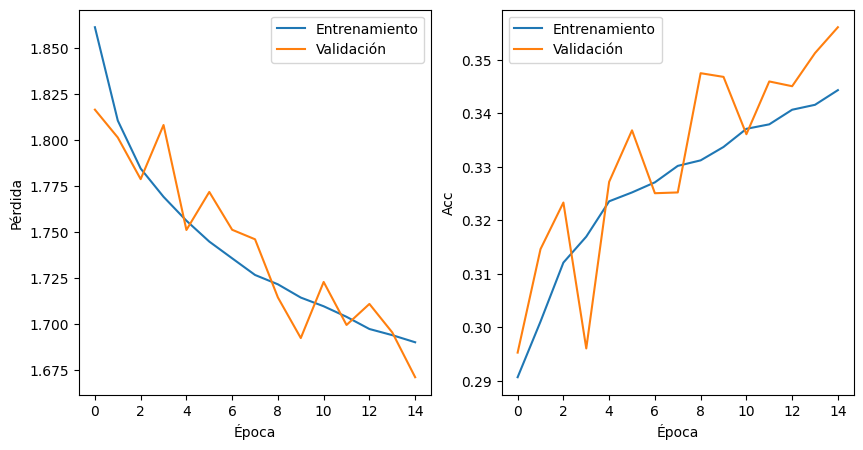

In [48]:
f,axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

axs[0].plot(train_losses, label='Entrenamiento')
axs[0].plot(val_losses, label='Validación')
axs[0].set_xlabel('Época')
axs[0].set_ylabel('Pérdida')
axs[0].legend()

axs[1].plot(train_accs, label='Entrenamiento')
axs[1].plot(val_accs, label='Validación')
axs[1].set_xlabel('Época')
axs[1].set_ylabel('Acc')
axs[1].legend()
plt.show()

## Resultados

Los resultados no muestran una mejoría tan significativa entre si; es importante ver las escalas porque no son tan distintas. Pero de manera muy general, la red **ViTRes** si tiene ligeramente un mejor desempeño, tanto en el set de entrenamiento y validación. 

En tiempo de ejecución la red VitRes se tardó un poco más, pero nada que sea significativo. De trabajo futuro se podría intentar agregar solamente conecciones residuales simplificando los bloques ResNet para intentar mejorar la velocidad de procesamiento sin tener un impacto tan grande en la Acc.